In [5]:
"""
Web scraping script — combined e-commerce dataset from three sources.

Source 1: scrapeme.live/shop      (~755 products: Pokemon merchandise, WooCommerce)
Source 2: webscraper.io test-sites/e-commerce/allinone
          (Phones > Touch, Computers > Laptops, Computers > Tablets — includes
          star ratings and review counts, ~147 products; this site has no
          pagination, each category page shows its full catalog)
Source 3: dummyjson.com/products  (public JSON API, 194 real varied products
          across many categories, includes rating and brand out of the box)
"""

import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

HEADERS = {"User-Agent": "capstone-project-scraper/1.0 (educational use)"}
GBP_TO_USD = 1.27  # fixed illustrative rate


# ---------------------------------------------------------------------------
# SOURCE 1: scrapeme.live/shop
# ---------------------------------------------------------------------------
def scrape_scrapeme():
    BASE = "https://scrapeme.live/shop/"
    records = []
    page = 1
    while True:
        page_url = urljoin(BASE, f"page/{page}/") if page > 1 else BASE
        try:
            resp = requests.get(page_url, headers=HEADERS, timeout=10)
        except requests.RequestException as e:
            print(f"[scrapeme] request failed on page {page}: {e}")
            break

        if resp.status_code == 404:
            print(f"[scrapeme] reached last page — stopped at page {page}.")
            break
        resp.raise_for_status()

        soup = BeautifulSoup(resp.text, "html.parser")
        items = soup.select("ul.products li.product")
        if not items:
            print(f"[scrapeme] no products on page {page} — stopping.")
            break

        for item in items:
            name_el = item.select_one("h2")
            price_el = item.select_one("span.price")
            link_el = item.select_one("a")
            img_el = item.select_one("img")
            if not (name_el and price_el and link_el):
                continue
            try:
                price_gbp = float(price_el.get_text(strip=True).replace("£", ""))
            except ValueError:
                continue

            records.append({
                "name": name_el.get_text(strip=True),
                "price_usd": round(price_gbp * GBP_TO_USD, 2),
                "category": "Pokemon Merchandise",
                "rating": None,
                "review_count": None,
                "image_url": img_el["src"] if img_el else None,
                "product_url": urljoin(page_url, link_el["href"]),
                "source": "scrapeme.live",
            })

        print(f"[scrapeme] page {page}: {len(items)} products -> {len(records)} total so far")
        page += 1
        time.sleep(0.4)

    return records


# ---------------------------------------------------------------------------
# SOURCE 2: webscraper.io test-sites/e-commerce/allinone
# ---------------------------------------------------------------------------
CATEGORY_PATHS = {
    "Phones - Touch": "phones/touch",
    "Computers - Laptops": "computers/laptops",
    "Computers - Tablets": "computers/tablets",
}
WS_BASE = "https://webscraper.io/test-sites/e-commerce/allinone/"


def scrape_webscraperio():
    records = []
    for category_name, path in CATEGORY_PATHS.items():
        page = 1
        while True:
            url = urljoin(WS_BASE, path) + ("" if page == 1 else f"?page={page}")
            try:
                resp = requests.get(url, headers=HEADERS, timeout=10)
                resp.raise_for_status()
            except requests.RequestException as e:
                print(f"[webscraper.io] request failed on {url}: {e}")
                break

            soup = BeautifulSoup(resp.text, "html.parser")
            items = soup.select("div.thumbnail")
            if not items:
                break

            for item in items:
                title_el = item.select_one("a.title")
                price_el = item.select_one("h4.price, h4.pull-right.price")
                review_el = item.select_one("p.review-count")
                stars = item.select("div.ratings p[data-rating] span.glyphicon-star")
                # fallback: count filled star icons if data-rating attr not present
                rating = len(stars) if stars else None

                if not (title_el and price_el):
                    continue
                try:
                    price = float(price_el.get_text(strip=True).replace("$", ""))
                except ValueError:
                    continue

                review_count = None
                if review_el:
                    digits = "".join(c for c in review_el.get_text() if c.isdigit())
                    review_count = int(digits) if digits else None

                records.append({
                    "name": title_el.get("title", title_el.get_text(strip=True)),
                    "price_usd": price,
                    "category": category_name,
                    "rating": rating,
                    "review_count": review_count,
                    "image_url": None,
                    "product_url": urljoin(url, title_el["href"]),
                    "source": "webscraper.io",
                })

            print(f"[webscraper.io] {category_name} page {page}: {len(items)} products")

            next_link = soup.select_one("ul.pagination li a[rel='next']")
            if not next_link:
                break
            page += 1
            time.sleep(0.4)

    return records


# ---------------------------------------------------------------------------
# SOURCE 3: dummyjson.com/products (public JSON API)
# ---------------------------------------------------------------------------
def scrape_dummyjson():
    records = []
    url = "https://dummyjson.com/products?limit=0"  # limit=0 returns all items
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"[dummyjson] request failed: {e}")
        return records

    products = resp.json().get("products", [])
    for p in products:
        reviews = p.get("reviews")
        review_count = len(reviews) if isinstance(reviews, list) else None

        records.append({
            "name": p.get("title"),
            "price_usd": p.get("price"),
            "category": p.get("category", "Uncategorized").replace("-", " ").title(),
            "rating": p.get("rating"),
            "review_count": review_count,
            "image_url": p.get("thumbnail"),
            "product_url": f"https://dummyjson.com/products/{p.get('id')}",
            "source": "dummyjson.com",
        })

    print(f"[dummyjson] fetched {len(records)} products")
    return records


def main():
    all_records = []
    print("Scraping Source 1: scrapeme.live ...")
    all_records.extend(scrape_scrapeme())

    print("\nScraping Source 2: webscraper.io ...")
    all_records.extend(scrape_webscraperio())

    print("\nScraping Source 3: dummyjson.com ...")
    all_records.extend(scrape_dummyjson())

    df = pd.DataFrame(all_records).drop_duplicates(subset="product_url").reset_index(drop=True)
    df.to_csv("ecommerce_raw.csv", index=False)
    print(f"\nTotal combined records: {len(df)}")
    print(df["source"].value_counts())
    print(df.head())


if __name__ == "__main__":
    main()

Scraping Source 1: scrapeme.live ...
[scrapeme] page 1: 16 products -> 16 total so far
[scrapeme] page 2: 16 products -> 32 total so far
[scrapeme] page 3: 16 products -> 48 total so far
[scrapeme] page 4: 16 products -> 64 total so far
[scrapeme] page 5: 16 products -> 80 total so far
[scrapeme] page 6: 16 products -> 96 total so far
[scrapeme] page 7: 16 products -> 112 total so far
[scrapeme] page 8: 16 products -> 128 total so far
[scrapeme] page 9: 16 products -> 144 total so far
[scrapeme] page 10: 16 products -> 160 total so far
[scrapeme] page 11: 16 products -> 176 total so far
[scrapeme] page 12: 16 products -> 192 total so far
[scrapeme] page 13: 16 products -> 208 total so far
[scrapeme] page 14: 16 products -> 224 total so far
[scrapeme] page 15: 16 products -> 240 total so far
[scrapeme] page 16: 16 products -> 256 total so far
[scrapeme] page 17: 16 products -> 272 total so far
[scrapeme] page 18: 16 products -> 288 total so far
[scrapeme] page 19: 16 products -> 304 tot

In [7]:
import pandas as pd
df = pd.read_csv('ecommerce_raw.csv')
print(df.shape)
print(df.isnull().sum())
print(df['source'].value_counts())
print(df['category'].value_counts())

(1096, 8)
name              0
price_usd         0
category          0
rating          902
review_count    755
image_url       147
product_url       0
source            0
dtype: int64
source
scrapeme.live    755
dummyjson.com    194
webscraper.io    147
Name: count, dtype: int64
category
Pokemon Merchandise    755
Computers - Laptops    117
Kitchen Accessories     30
Groceries               27
Computers - Tablets     21
Sports Accessories      17
Smartphones             16
Mobile Accessories      14
Phones - Touch           9
Mens Watches             6
Home Decoration          5
Furniture                5
Womens Shoes             5
Womens Dresses           5
Womens Bags              5
Vehicle                  5
Tops                     5
Sunglasses               5
Beauty                   5
Fragrances               5
Motorcycle               5
Mens Shoes               5
Mens Shirts              5
Laptops                  5
Womens Watches           5
Tablets                  3
Skin Care 

In [8]:
counts = df["category"].value_counts()
rare = counts[counts < 10].index
df["category"] = df["category"].apply(lambda c: "Other" if c in rare else c)
print(df["category"].value_counts())

category
Pokemon Merchandise    755
Computers - Laptops    117
Other                   99
Kitchen Accessories     30
Groceries               27
Computers - Tablets     21
Sports Accessories      17
Smartphones             16
Mobile Accessories      14
Name: count, dtype: int64


In [9]:
df["name_length"] = df["name"].str.len()
df["price_band"] = pd.cut(
    df["price_usd"], bins=[0, 20, 60, 150, 100000],
    labels=["budget", "mid", "premium", "luxury"]
)

df.to_csv("ecommerce_clean.csv", index=False)
print("Clean shape:", df.shape)
df.head()

Clean shape: (1096, 10)


,name,price_usd,category,rating,review_count,image_url,product_url,source,name_length,price_band
0,Bulbasaur,80.01,Pokemon Merchandise,NaN,NaN,https://scrapeme.live/wp-content/uploads/2018/...,https://scrapeme.live/shop/Bulbasaur/,scrapeme.live,9,premium
1,Ivysaur,110.49,Pokemon Merchandise,NaN,NaN,https://scrapeme.live/wp-content/uploads/2018/...,https://scrapeme.live/shop/Ivysaur/,scrapeme.live,7,premium
2,Venusaur,133.35,Pokemon Merchandise,NaN,NaN,https://scrapeme.live/wp-content/uploads/2018/...,https://scrapeme.live/shop/Venusaur/,scrapeme.live,8,premium
3,Charmander,60.96,Pokemon Merchandise,NaN,NaN,https://scrapeme.live/wp-content/uploads/2018/...,https://scrapeme.live/shop/Charmander/,scrapeme.live,10,premium
4,Charmeleon,209.55,Pokemon Merchandise,NaN,NaN,https://scrapeme.live/wp-content/uploads/2018/...,https://scrapeme.live/shop/Charmeleon/,scrapeme.live,10,luxury


In [10]:
df["price_usd"].describe()

count     1096.000000
mean       479.799781
std       2383.842232
min          0.790000
25%         74.930000
50%        146.050000
75%        224.790000
max      36999.990000
Name: price_usd, dtype: float64

In [11]:
df.sort_values("price_usd", ascending=False).head(10)[["name", "price_usd", "category", "source"]]

,name,price_usd,category,source
1071,Durango SXT RWD,36999.99,Other,dummyjson.com
1069,Charger SXT RWD,32999.99,Other,dummyjson.com
1072,Pacifica Touring,31999.99,Other,dummyjson.com
1068,300 Touring,28999.99,Other,dummyjson.com
1070,Dodge Hornet GT Plus,24999.99,Other,dummyjson.com
1092,Rolex Cellini Moonphase,15999.99,Other,dummyjson.com
1016,MotoGP CI.H1,14999.99,Other,dummyjson.com
999,Rolex Submariner Watch,13999.99,Other,dummyjson.com
997,Rolex Cellini Moonphase,12999.99,Other,dummyjson.com
998,Rolex Datejust,10999.99,Other,dummyjson.com


In [19]:
import numpy as np

df["price_log"] = np.log10(df["price_usd"])

In [14]:
df.to_csv("ecommerce_clean.csv", index=False)

In [21]:
import numpy as np

df["price_log"] = np.log10(df["price_usd"])
df[["name", "price_usd", "price_log"]].head()

,name,price_usd,price_log
0,Bulbasaur,80.01,1.903144
1,Ivysaur,110.49,2.043323
2,Venusaur,133.35,2.124993
3,Charmander,60.96,1.785045
4,Charmeleon,209.55,2.321288


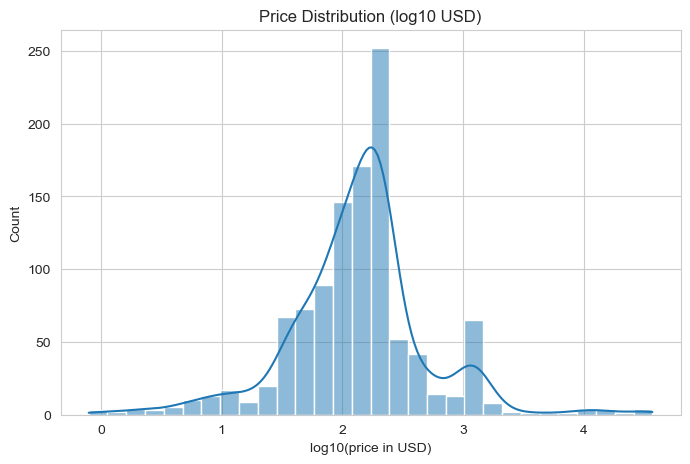

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df["price_log"], bins=30, kde=True)
plt.title("Price Distribution (log10 USD)")
plt.xlabel("log10(price in USD)")
plt.savefig("chart_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

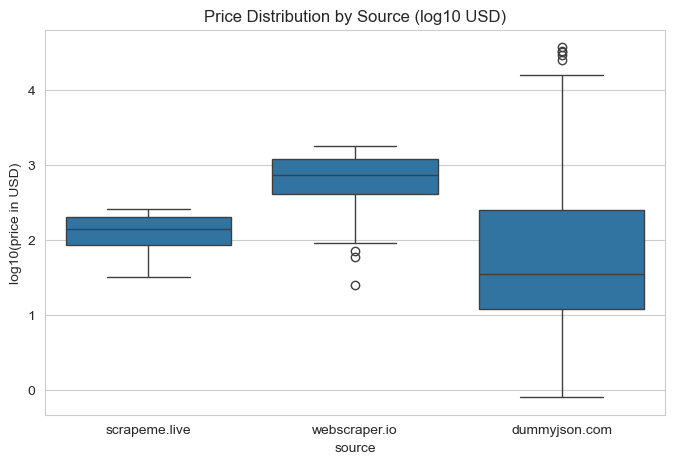

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="source", y="price_log")
plt.title("Price Distribution by Source (log10 USD)")
plt.ylabel("log10(price in USD)")
plt.savefig("chart_price_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

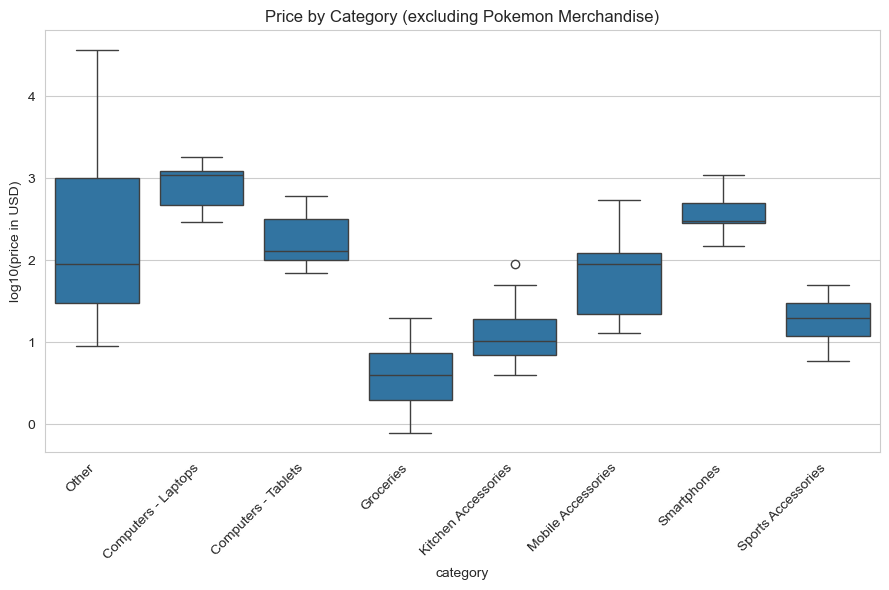

In [24]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df[df["source"] != "scrapeme.live"], x="category", y="price_log")
plt.title("Price by Category (excluding Pokemon Merchandise)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("log10(price in USD)")
plt.tight_layout()
plt.savefig("chart_price_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

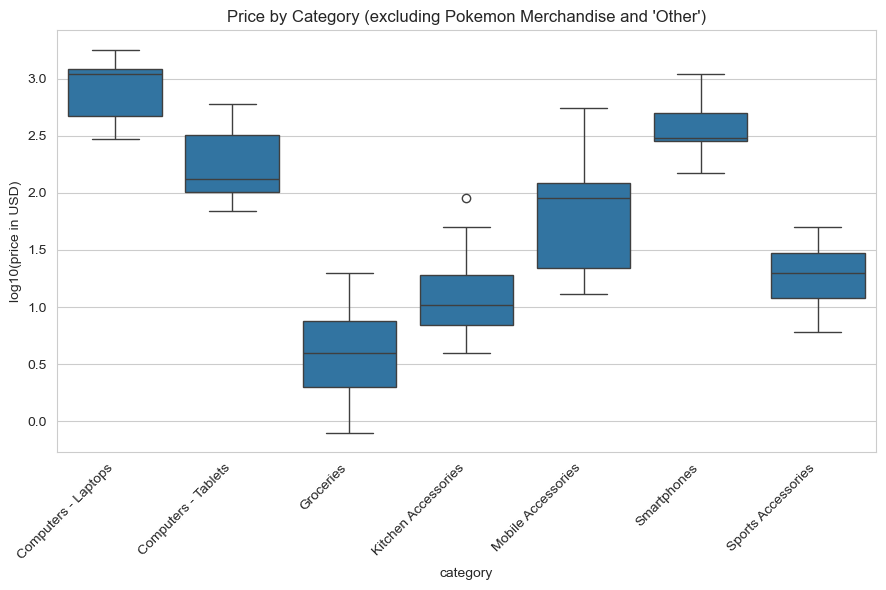

In [25]:
chart_data = df[(df["source"] != "scrapeme.live") & (df["category"] != "Other")]

plt.figure(figsize=(9, 6))
sns.boxplot(data=chart_data, x="category", y="price_log")
plt.title("Price by Category (excluding Pokemon Merchandise and 'Other')")
plt.xticks(rotation=45, ha="right")
plt.ylabel("log10(price in USD)")
plt.tight_layout()
plt.savefig("chart_price_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

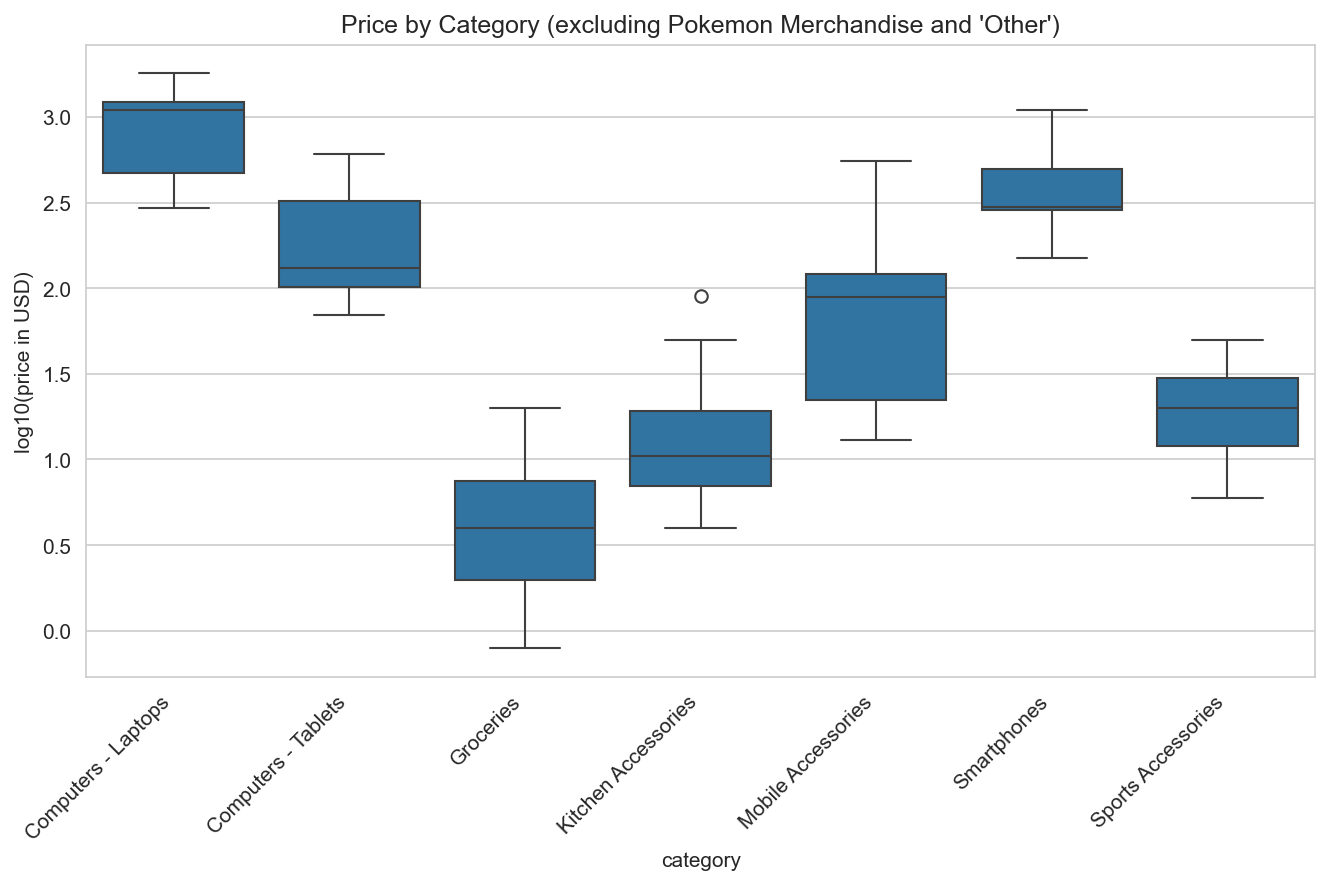

In [26]:
from IPython.display import Image; Image("chart_price_by_category.png")

In [28]:
print(sorted(chart_data["category"].unique()))

['Computers - Laptops', 'Computers - Tablets', 'Groceries', 'Kitchen Accessories', 'Mobile Accessories', 'Smartphones', 'Sports Accessories']


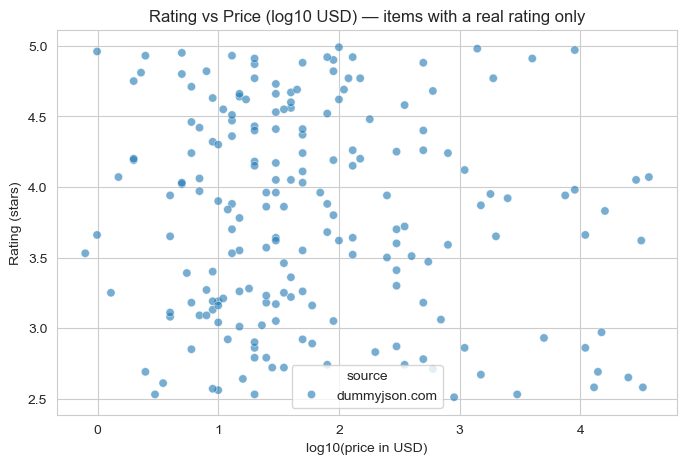

In [29]:
rated = df.dropna(subset=["rating"])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rated, x="price_log", y="rating", hue="source", alpha=0.6)
plt.title("Rating vs Price (log10 USD) — items with a real rating only")
plt.xlabel("log10(price in USD)")
plt.ylabel("Rating (stars)")
plt.savefig("chart_rating_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rated_only = df.dropna(subset=["rating"]).copy()
rated_only["high_rated"] = (rated_only["rating"] >= 4).astype(int)

features = pd.get_dummies(rated_only[["price_log", "name_length", "category"]], columns=["category"])
target = rated_only["high_rated"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("Confusion matrix:\n", confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.62      0.70      0.65        23
           1       0.46      0.38      0.41        16

    accuracy                           0.56        39
   macro avg       0.54      0.54      0.53        39
weighted avg       0.55      0.56      0.55        39

ROC AUC: 0.5665760869565217
Confusion matrix:
 [[16  7]
 [10  6]]


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

cluster_features = df[["price_log", "name_length"]].dropna()
X_scaled = StandardScaler().fit_transform(cluster_features)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[cluster_features.index, "segment"] = km.fit_predict(X_scaled)

print(df.groupby("segment")[["price_log", "name_length"]].mean())
print(df.groupby("segment")["source"].value_counts())

         price_log  name_length
segment                        
0.0       2.167245     7.635211
1.0       2.609295    29.934066
2.0       1.349114    10.674641
3.0       3.169882    17.511628
segment  source       
0.0      scrapeme.live    663
         webscraper.io     30
         dummyjson.com     17
1.0      webscraper.io     56
         dummyjson.com     35
2.0      dummyjson.com    114
         scrapeme.live     92
         webscraper.io      3
3.0      webscraper.io     58
         dummyjson.com     28
Name: count, dtype: int64


In [2]:
import os; print(os.getcwd())

C:\Users\Laxmi\OneDrive\Internshala\Project\Multi-Source E-Commerce Project
